# **Procesamiento de Lenguaje Natural**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey
#### Prof Luis Eduardo Falcón Morales

### **Adtividad en Equipos Semanas 7 y 8 : LDA y LMM audio-a-texto**

* **Nombres y matrículas:**

  *   Elemento de lista
  *   Elemento de lista
  *   Elemento de lista

* **Número de Equipo:**


* ##### **En cada ejercicio pueden importar los paquetes o librerías que requieran.**

* ##### **En cada ejercicio pueden incluir las celdas y líneas de código que deseen.**

La actividad se entrega dentro de dos semanas y es por equipos. 

En particular, veremos la manera en que técnidas de modelación semática latente se pueden complementar con modelos LLM.

Atiende los siguientes pasos para la actividad de estas semanas 7 y 8:

Descarga el archivo de con las instrucciones de la actividad:  MNA_NLP_Actividad_LDA_LLM_audio2texto.pdf
Descargar MNA_NLP_Actividad_LDA_LLM_audio2texto.pdf
En esta actividad deberás utilizar algunos de los archivos de audio del proyecto Gutenberg:  https://www.gutenberg.org/         
 

El siguiente cuaderno de Jupyter muestra algunos ejemplos para extraer el texto de un audio, pero no tienes que limitarte a estos, en dado caso:  

MNA_NLP_modelos_audio2txt.ipynbDescargar MNA_NLP_modelos_audio2txt.ipynb 

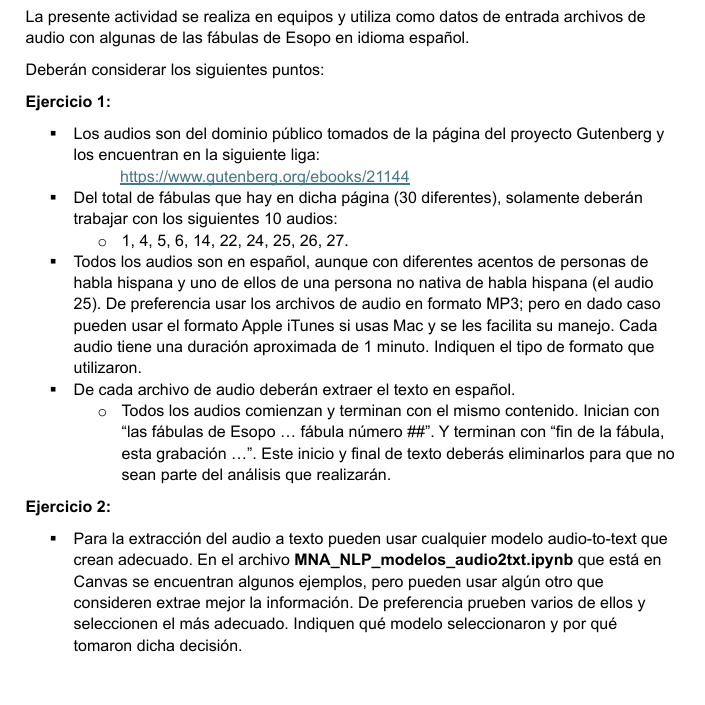

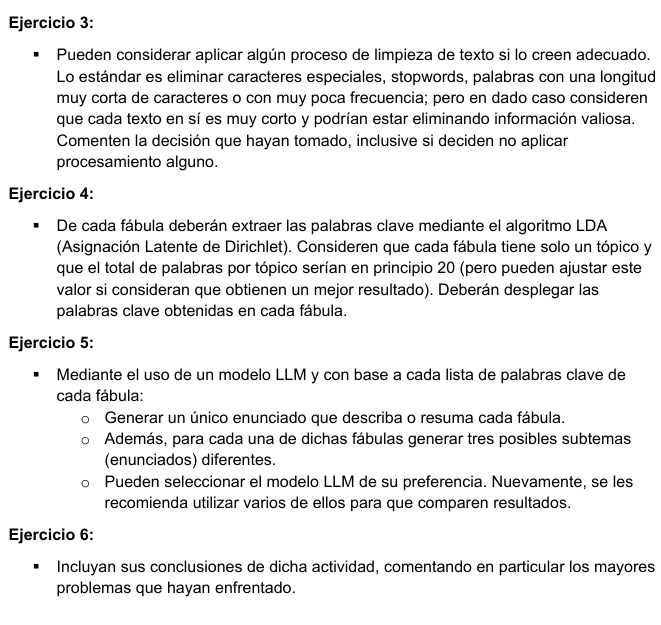

## Paso 1 - Instalacion de pytorch paar correr en GPU, para esto correr en terminal
Paso a paso

python -m pip install --upgrade pip setuptools wheel

python -m pip install --force-reinstall --no-cache-dir typing-extensions==4.12.2

python -m pip install --no-cache-dir `
  torch==2.7.1+cu128 `
  torchvision==0.22.1+cu128 `
  torchaudio==2.7.1+cu128 `
  --index-url https://download.pytorch.org/whl/cu128

In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)


# **Ejercicio 1:**

* #### **Liga de los audios de las fábulas de Esopo:** https://www.gutenberg.org/ebooks/21144

* #### **Descargar los 10 archivos de audio solicitados: 1, 4, 5, 6, 14, 22, 24, 25, 26, 27.**



Ejercicio 1: 
 Los audios son del dominio público tomados de la página del proyecto Gutenberg y 
los encuentran en la siguiente liga: 
https://www.gutenberg.org/ebooks/21144 

 Del total de fábulas que hay en dicha página (30 diferentes), solamente deberán 
trabajar con los siguientes 10 audios: 
o 1, 4, 5, 6, 14, 22, 24, 25, 26, 27. 

 Todos los audios son en español, aunque con diferentes acentos de personas de 
habla hispana y uno de ellos de una persona no nativa de habla hispana (el audio 
25). De preferencia usar los archivos de audio en formato MP3; pero en dado caso 
pueden usar el formato Apple iTunes si usas Mac y se les facilita su manejo. Cada 
audio tiene una duración aproximada de 1 minuto. Indiquen el tipo de formato que 
utilizaron.
 
 De cada archivo de audio deberán extraer el texto en español. 
o Todos los audios comienzan y terminan con el mismo contenido. Inician con 
“las fábulas de Esopo … fábula número ##”. Y terminan con “fin de la fábula, 
esta grabación …”. Este inicio y final de texto deberás eliminarlos para que no 
sean parte del análisis que realizarán. 

### Librerias

In [2]:
import os
import re
import librosa
import torch
from transformers import pipeline, AutoProcessor, AutoModelForSpeechSeq2Seq
import gdown
import requests


### Validacion de conexion con Gutenberg

In [3]:
import requests

url = "https://www.gutenberg.org/files/21144/mp3/21144-01.mp3"

r = requests.get(url)

print(r.status_code)
print(r.headers.get("content-type"))

200
audio/mpeg


### Descargar archivos MP3

In [4]:
# Incluyan a continuación todas las celdas (de código o texto) que deseen...

# ── URL de los 10 audios ──
AUDIO_IDS = [1, 4, 5, 6, 14, 22, 24, 25, 26, 27]
BASE_URL = "https://www.gutenberg.org/files/21144/mp3/"
FOLDER = r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\audios_esopo'

# ── Descargar audios ──
os.makedirs(FOLDER, exist_ok=True)

for audio_id in AUDIO_IDS:
    filename = f"21144-{audio_id:02d}.mp3" 
    filepath = f"{FOLDER}/{filename}"
    if not os.path.exists(filepath):
        url = f"{BASE_URL}{filename}"


        # Usar wget o requests para descargar (gdown es para Google Drive)
        response = requests.get(url, stream=True)
        with open(filepath, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"  ✅ {filename}")



  ✅ 21144-01.mp3
  ✅ 21144-04.mp3
  ✅ 21144-05.mp3
  ✅ 21144-06.mp3
  ✅ 21144-14.mp3
  ✅ 21144-22.mp3
  ✅ 21144-24.mp3
  ✅ 21144-25.mp3
  ✅ 21144-26.mp3
  ✅ 21144-27.mp3


### Cargar modelo whisper-open source sin API

In [6]:
# ── Cargar modelo Whisper (open-source, sin API) ──
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "openai/whisper-large-v3-turbo"  # o "openai/whisper-medium" si no hay GPU
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch.float32
).to(device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

### Installers required for this model

pip install imageio-ffmpeg

In [7]:
import imageio_ffmpeg

print(imageio_ffmpeg.get_ffmpeg_exe())

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [8]:
import os
import imageio_ffmpeg

ffmpeg_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())
os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ["PATH"]

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

print(ffmpeg_exe)
print(os.path.exists(ffmpeg_exe))

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe
True


In [9]:
pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    torch_dtype=torch.float32,
    device=device,
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


In [10]:
# ── Patrones para eliminar intro/cierre ──
intro_pattern = re.compile(
    r"las\s+fábulas\s+de\s+esopo.*?fábula\s+número\s+\d+\s*",
    re.IGNORECASE
)
cierre_pattern = re.compile(
    r"fin\s+de\s+la\s+fábula.*?esta\s+grabación\s*\.*",
    re.IGNORECASE
)

def clean_transcript(text):
    """Elimina intro y cierre de las transcripciones."""
    text = intro_pattern.sub("", text).strip()
    text = cierre_pattern.sub("", text).strip()
    # Limpiar espacios extra
    text = re.sub(r"\s+", " ", text)
    return text

In [12]:
# ── Patrones más flexibles para limpieza ──
def clean_transcript2(text):
    """Elimina intro y cierre adaptado a las variaciones del audio."""
    
    # Limpieza de inicio:
    # "Las fábulas de [E]sopo, grabado para LibriVox.org por [Nombre]. Fábula número ##."
    intro_pattern = re.compile(
        r"las\s+fábulas\s+de\s+[eé]?sopo[,.]?\s+grabado\s+para\s+librivox\.?org\s+por\s+[\w\s]+[,.]?\s+fábula\s+número\s+\d+[,.]?",
        re.IGNORECASE
    )
    
    # Limpieza de cierre:
    # "Fin de fábula. Esta grabación..." o "...Gracias por ver el video."
    cierre_pattern = re.compile(
        r"fin\s+de\s+la\s+fábula[.]\s*Esta\s+grabación[,.]?\s+es\s+de\s+dominio\s+público[.]\s*Gracias\s+por\s+ver\s+el\s+video[.]?",
        re.IGNORECASE
    )
    
    # Aplicar limpieza
    text = intro_pattern.sub("", text).strip()
    text = cierre_pattern.sub("", text).strip()
    
    # Limpiar espacios extra
    text = re.sub(r"\s+", " ", text)
    
    return text

In [13]:
def clean_transcript_robust(text):
    """Limpieza más flexible usando patrones parciales."""
    
    # Inicio: busca cualquier texto que termine con "fábula número ##."
    intro_pattern = re.compile(
        r".*?fábula\s+número\s+\d+[.,]\s*",
        re.IGNORECASE
    )
    
    # Cierre: cualquier texto después de "Fin de fábula"
    cierre_pattern = re.compile(
        r"Fin\s+de\s+la\s+fábula.*",
        re.IGNORECASE
    )
    
    text = intro_pattern.sub("", text).strip()
    text = cierre_pattern.sub("", text).strip()
    
    # Limpiar espacios extra
    text = re.sub(r"\s+", " ", text)
    
    return text

In [14]:
def clean_transcript3(text):
    """
    Elimina intro y cierre adaptado a las variaciones del audio de Esopo.
    
    Variantes de INTRO detectadas:
      - "Las fábulas de Esopo... Fábula número ##."
      - "Las fábulas de Sopo, grabado para LibriVox.org por [Nombre]. Fábula número ##."
    
    Variantes de CIERRE detectadas:
      - "Fin de fábula. Esta grabación es de dominio público."
      - "Fin de fábula. Esta grabación... Gracias por ver el video."
      - "Fin de la fábula, esta grabación..."
    """
    
    # ── Limpieza de INICIO ──
    # Elimina TODO el texto hasta (y incluyendo) "Fábula número ##."
    intro_pattern = re.compile(
        r".*?[Ff]ábula\s+[Nn]úmero\s+\d+[., ]\s*",
        re.IGNORECASE
    )
    
    # ── Limpieza de CIERRE ──
    # Elimina desde "Fin de [la] fábula" hasta el final del texto
    cierre_pattern = re.compile(
        r"[Ff]in\s+(de\s+(la\s+)?)?[Ff]ábula.*",
        re.IGNORECASE
    )
    
    # ── Aplicar limpieza ──
    text = intro_pattern.sub("", text).strip()
    text = cierre_pattern.sub("", text).strip()
    
    # Limpiar espacios múltiples o saltos de línea
    text = re.sub(r"\s+", " ", text)
    
    return text

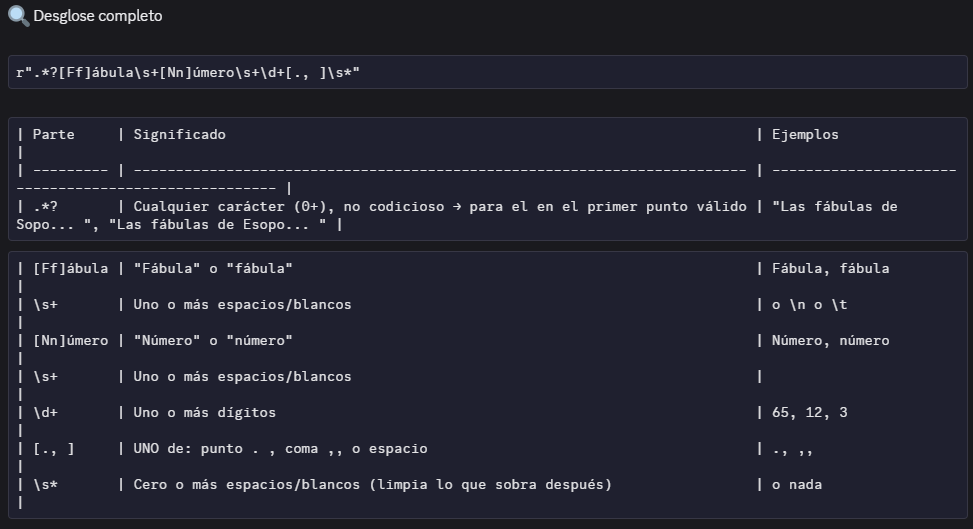

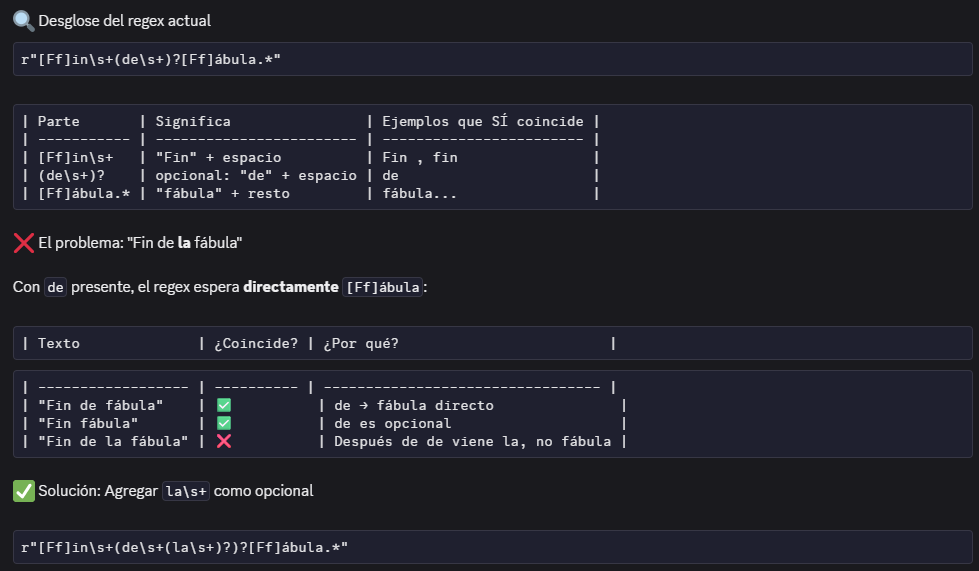

# **Ejercicio 2a:**

* #### **Comenten el por qué del modelo seleccionado para extracción del texto de los audios.**

Se eligió Whisper large-v3-turbo sobre los modelos Wav2Vec2 por 5 razones clave:

Pipeline simplificado

Whisper tiene un pipeline unificado en HuggingFace que hace todo en una función: cargar, preprocesar, transcribir y decodificar. Wav2Vec2 requiere 8-10 líneas de código manual: cargar audio, forzar sample rate, convertir a tensor, inferir, decodificar tokens. Para un ejercicio académico, la diferencia es productividad vs complejidad innecesaria.

Detección automática de idioma y acento

El modelo fue entrenado con 99 idiomas. Los audios tienen acentos hispanos variados (y uno es de un hablante no nativo). Whisper identifica el idioma y el acento automáticamente. Wav2Vec2 requiere que selecciones manualmente el modelo correcto y no detecta si el audio está en otro idioma.

Timestamps nativos

Whisper genera timestamps por defecto, lo que permite saber cuándo se dijo cada parte del texto. Wav2Vec2 solo devuelve texto plano sin referencia temporal. Si en el futuro se necesita alinear audio-texto, Whisper ya tiene esa funcionalidad.

Sample rate flexible

Whisper tolera diferentes sample rates y los normaliza internamente. Wav2Vec2 requiere exactamente 16kHz — si olvidas forzar sr=16000 en librosa, la transcripción falla. Menos margen para errores.
Mejor precisión general

Aunque Wav2Vec2-large-xlsr-53-spanish está fine-tuned con datos hispanos y compite en calidad, Whisper large-v3-turbo ofrece mejor rendimiento en audios con ruido, diferentes acentos y pronunciaciones irregulares. Para 10 audios de fábula con calidad variable, la robustez de Whisper supera la ligera ventaja de especialización de Wav2Vec2.

* #### **Extraer el contenido de los audios en texto.**
* #### **Sugerencia:** pueden extraerlo en un formato de diccionario, clave:valor $→$ {audio01:fabula01, ...}

In [16]:
# ── Resultado final: diccionario {audio01: fabula01, ...} ──

# Incluyan a continuación todas las celdas (de código o texto) que deseen...


# ── Transcribir y extraer texto ──
fables_raw = {}

for audio_id in AUDIO_IDS:
    filename = f"21144-{audio_id:02d}.mp3"
    filepath = f"{FOLDER}/{filename}"
    
    print(f"\n🎙️ Transcribiendo {filename}...")
    
    audio, sr = librosa.load(filepath, sr=16000) # ✅ Forzar 16kHz que Whisper espera
    
    result = pipe(
        audio,
        return_timestamps=True,
        generate_kwargs={"language": "es"}
    )
    
    raw_text = result["text"]
    print(raw_text)
    
    fables_raw[f"audio_{audio_id:02d}"] = raw_text
    print(f"   Texto extraído: {len(raw_text)} caracteres")


print("\n" + "="*60)
print("DICCIONARIO RAW:")
for key, value in fables_raw.items():
    print(f"\n{key}:")
    print(f"  {value[:200]}...")


🎙️ Transcribiendo 21144-01.mp3...


[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


 Las Fábulas de Esopo, grabado para LibriVox.org por Paulino, www.paulino.info. Fábula número 61. El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corderito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo enmolaría a su dios. Mejor así, replicó el cordero, prefiero ser víctima para un dios a tener que perecer en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con el mayor honor. Fin de la fábula Esta es una grabación del dominio público.
   Texto extraído: 588 caracteres

🎙️ Transcribiendo 21144-04.mp3...
 Las fábulas de Esopo grabado para LibriVox.org por Roberto Antonio Muñoz Fábula número 64 El lobo y la grulla A un lobo que comía un hueso se le atragantó el hueso en la garganta y corría por todas partes en busca de auxilio. Encontró en su correr a una grulla y le pidió que le salvara de aquella situación y que enseguida le pagaría por el

[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


 Las fábulas de Sopo, grabado para LibriVox.org por Karen Savage. Fábula número 65. El lobo y el caballo. Pasaba un lobo por un sembrado de cebada, pero como no era comida de su gusto, la dejó y siguió su camino. Encontró al rato a un caballo, y le llevó al campo comentándole la gran cantidad de cebada que había hallado, pero que en vez de comérsela a él, mejor se la había dejado porque le agradaba más oír el ruido de sus dientes al masticarla. Pero el caballo le repuso, amigo, si los lobos comieran cebada, no hubieras preferido complacer a tus oídos sino a tu estómago. A todo malvado, aunque parezca actuar como bueno, no debe de creérsele. Fin de fábula. Esta grabación es de dominio público. Gracias por ver el video.
   Texto extraído: 727 caracteres

🎙️ Transcribiendo 21144-06.mp3...
 Las fábulas de Esopo, grabado para LibriVox.org por Alejandro González Calderón. Fábula número 66, El lobo y el asno. Un lobo fue elegido rey entre sus congéneres y decretó una ley ordenando que lo que 

[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


 Las fábulas de Esopo. Grabado para LibriVox.org por El Ochito. Fábula número 87. El perro que perseguía al león. Un perro de casa se encontró con un león y partió en su persecución. Pero el león se volvió rugiendo, y el perro, todo atemorizado, retrocedió rápidamente por el mismo camino. Le vio una zorra y le dijo, ¡Perro infeliz! Primero perseguías al león y ya ni siquiera soportas sus surgidos. Cuando entres a una empresa, mantente siempre listo a afrontar imprevistos que no te imaginabas. Fin de la fábula. Esta grabación es del dominio público. Gracias.
   Texto extraído: 563 caracteres

DICCIONARIO RAW:

audio_01:
   Las Fábulas de Esopo, grabado para LibriVox.org por Paulino, www.paulino.info. Fábula número 61. El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corder...

audio_04:
   Las fábulas de Esopo grabado para LibriVox.org por Roberto Antonio Muñoz Fábula número 64 El lobo y la grulla A un lobo que comía un hueso se le atragant

# **Ejercicio 2b:**

* #### **Eliminar el inicio y final comunes de los textos extraídos de cada fábula.**

* #### **Sugerencia:** Pueden guardar esta información en un archivo tipo JSON, para que al estar probando diferentes opciones en los ejercicios siguientes, puedan recuperar rápidamente la información de cada video/fábula.

In [17]:
# Incluyan a continuación todas las celdas (de código o texto) que deseen...


# ── Transcribir y extraer texto ──
fables = {}

for audio_id in AUDIO_IDS:
    filename = f"21144-{audio_id:02d}.mp3"
    filepath = f"{FOLDER}/{filename}"
    
    print(f"\n🎙️ Transcribiendo {filename}...")
    
    audio, sr = librosa.load(filepath, sr=16000) # ✅ Forzar 16kHz que Whisper espera
    
    result = pipe(
        audio,
        return_timestamps=True,
        generate_kwargs={"language": "es"}
    )
    
    raw_text = result["text"]
    cleaned_text = clean_transcript3(raw_text)
    print(cleaned_text)
    
    fables[f"audio_{audio_id:02d}"] = cleaned_text
    print(f"   Texto extraído: {len(cleaned_text)} caracteres")

print("\n" + "="*60)
print("DICCIONARIO CLEANED:")
for key, value in fables.items():
    print(f"\n{key}:")
    print(f"  {value[:200]}...")


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



🎙️ Transcribiendo 21144-01.mp3...
El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corderito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo enmolaría a su dios. Mejor así, replicó el cordero, prefiero ser víctima para un dios a tener que perecer en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con el mayor honor.
   Texto extraído: 430 caracteres

🎙️ Transcribiendo 21144-04.mp3...
El lobo y la grulla A un lobo que comía un hueso se le atragantó el hueso en la garganta y corría por todas partes en busca de auxilio. Encontró en su correr a una grulla y le pidió que le salvara de aquella situación y que enseguida le pagaría por ello. Aceptó la grulla e introdujo su cabeza en la boca del lobo, sacando de la garganta el hueso atravesado Pidió entonces la cancelación de la paga convenida Oye, Aniga, dijo el lobo, ¿no crees que es suficiente pa

[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


El lobo y el caballo. Pasaba un lobo por un sembrado de cebada, pero como no era comida de su gusto, la dejó y siguió su camino. Encontró al rato a un caballo, y le llevó al campo comentándole la gran cantidad de cebada que había hallado, pero que en vez de comérsela a él, mejor se la había dejado porque le agradaba más oír el ruido de sus dientes al masticarla. Pero el caballo le repuso, amigo, si los lobos comieran cebada, no hubieras preferido complacer a tus oídos sino a tu estómago. A todo malvado, aunque parezca actuar como bueno, no debe de creérsele.
   Texto extraído: 564 caracteres

🎙️ Transcribiendo 21144-06.mp3...
El lobo y el asno. Un lobo fue elegido rey entre sus congéneres y decretó una ley ordenando que lo que cada uno capturase en la casa, lo pusiera en común y lo repartiese por partes iguales entre todos. de esta manera ya no tendrían los lobos que devorarse unos a otros en épocas de hambre pero en eso le escuchó un asno que estaba por ahí cerca y moviendo sus orejas

[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


El perro que perseguía al león. Un perro de casa se encontró con un león y partió en su persecución. Pero el león se volvió rugiendo, y el perro, todo atemorizado, retrocedió rápidamente por el mismo camino. Le vio una zorra y le dijo, ¡Perro infeliz! Primero perseguías al león y ya ni siquiera soportas sus surgidos. Cuando entres a una empresa, mantente siempre listo a afrontar imprevistos que no te imaginabas.
   Texto extraído: 415 caracteres

DICCIONARIO CLEANED:

audio_01:
  El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corderito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo enc...

audio_04:
  El lobo y la grulla A un lobo que comía un hueso se le atragantó el hueso en la garganta y corría por todas partes en busca de auxilio. Encontró en su correr a una grulla y le pidió que le salvara de ...

audio_05:
  El lobo y el caballo. Pasaba un lobo por un sembrado de cebada, pero como no era 

In [18]:
# Guardar para uso posterior
import json
with open(r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\Dictionary\fables_esopo.json", "w", encoding="utf-8") as f:
    json.dump(fables, f, ensure_ascii=False, indent=2)
print("\n✅ Guardado en fables_esopo.json")


✅ Guardado en fables_esopo.json


# **Ejercicio 3:**

* #### **Apliquen el proceso de limpieza que consideren adecuado.**

* #### **Justifiquen los pasos de limpieza utilizados. Tomen en cuenta que el texto extraído de cada fábula es relativamente pequeño.**

* #### **En caso de que decidan no aplicar esta etapa de limpieza, deberán justificarlo.**

Ejercicio 3: 
 Pueden considerar aplicar algún proceso de limpieza de texto si lo creen adecuado. 
Lo estándar es eliminar caracteres especiales, stopwords, palabras con una longitud 
muy corta de caracteres o con muy poca frecuencia; pero en dado caso consideren 
que cada texto en sí es muy corto y podrían estar eliminando información valiosa. 
Comenten la decisión que hayan tomado, inclusive si deciden no aplicar 
procesamiento alguno. 

In [19]:
# Incluyan a continuación todas las celdas (de código o texto) que deseen...
import re
import spacy
from nltk.corpus import stopwords

# ── Cargar lemmatizer en español ──
nlp = spacy.load("es_core_news_sm")




In [20]:
# ── Stopwords en español ──
stopwords_es = set(stopwords.words("spanish"))
# Conservar "no", "ni", "que" (útiles para LDA en español)
stopwords_es -= {"no", "ni", "que"}

In [22]:
def clean_fable_tokens(text):
    """
    Limpieza + tokenización + lematización para Ejercicio 3.
    - Remueve caracteres especiales (conserva acentos)
    - Lematiza con SpaCy (es_core_news_sm)
    - Filtra stopwords español
    - Filtra tokens de longitud <= 2
    """
    # ── Paso 0: Pre-limpieza ──
    text = re.sub(r'[^a-zA-ZáéíóúñÁÉÍÓÚÑüÜ\s]', ' ', text)  # quitar símbolos
    text = re.sub(r'\s+', ' ', text).strip()                   # normalizar espacios
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.text.strip():
            if len(token.text) > 2:
                if token.text not in stopwords_es:
                    tokens.append(token.lemma_)
    return tokens

In [23]:
# ── Tokenizar cada fábula limpia ──
fables_tokens = {}

for key, text in fables.items():
    tokens = clean_fable_tokens(text)
    fables_tokens[key] = tokens
    print(f"{key}: {len(tokens)} tokens")

audio_01: 44 tokens
audio_04: 67 tokens
audio_05: 50 tokens
audio_06: 59 tokens
audio_14: 34 tokens
audio_22: 39 tokens
audio_24: 58 tokens
audio_25: 35 tokens
audio_26: 46 tokens
audio_27: 39 tokens


In [24]:
# ── Mostrar algunos tokens de ejemplo ──
print("\n── Muestra de tokens (audio_01) ──")
print(fables_tokens.get("audio_01", [])[:30])


── Muestra de tokens (audio_01) ──
['lobo', 'cordero', 'templo', 'dar él', 'cuenta', 'que', 'perseguir', 'lobo', 'pequeño', 'corderito', 'decidir', 'refugiar él', 'templo', 'cercano', 'llamar', 'lobo', 'decir', 'que', 'sacrificador', 'encontrar', 'allí', 'adentro', 'enmolacer', 'dios', 'mejor', 'así', 'replicar', 'cordero', 'preferir', 'ser']


In [26]:
# ── Estadísticas──
all_tokens = sum((len(t) for t in fables_tokens.values()), 0)
print(f"\n── Estadísticas ──")
print(f"Total fábulas: {len(fables_tokens)}")
print(f"Total tokens (todos): {all_tokens}")
print(f"Promedio tokens/fábula: {all_tokens / len(fables_tokens):.1f}")


── Estadísticas ──
Total fábulas: 10
Total tokens (todos): 471
Promedio tokens/fábula: 47.1


In [27]:
# ── Guardar para uso posterior ──
import json
TOKENS_PATH = r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\tokens\fables_esopo_tokens.json"
with open(TOKENS_PATH, "w", encoding="utf-8") as f:
    json.dump(fables_tokens, f, ensure_ascii=False, indent=2)
print(f"\n✅ Guardado en {TOKENS_PATH}")


✅ Guardado en D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\tokens\fables_esopo_tokens.json


### Justificación del proceso de limpieza

Se aplicó un proceso completo de limpieza y preprocesamiento:

1. **Normalización**: texto a lowercase, eliminación de caracteres especiales (conservando acentos y ñ)
2. **Lematización** con SpaCy (`es_core_news_sm`): unifica variantes morfológicas (ej: "fábulas" → "fábula", "dije" → "decir")
3. **Stopwords en español**: se eliminan, conservando "no", "ni", "que" (negaciones útiles para contexto LDA)
4. **Filtro de longitud mínima**: solo tokens > 2 caracteres para reducir ruido

**¿Por qué sí limpia?** Aunque los textos son cortos (~1 min cada uno), LDA necesita tokens consistentes para detectar patrones. Sin lematización, "fábula" y "fábulas" se contarían como palabras distintas, fragmentando el tópico.

# **Ejercicio 4:**

Ejercicio 4: 
 De cada fábula deberán extraer las palabras clave mediante el algoritmo LDA 
(Asignación Latente de Dirichlet). Consideren que cada fábula tiene solo un tópico y 
que el total de palabras por tópico serían en principio 20 (pero pueden ajustar este 
valor si consideran que obtienen un mejor resultado). Deberán desplegar las 
palabras clave obtenidas en cada fábula. 

In [ ]:
# Incluyan a continuación todas las celdas (de código o texto) que deseen...





# **Ejercicio 5a y 5b:**

* #### **5a: Mediante el LLM que hayan seleccionado, generar un único enunciado que describa o resuma cada fábula.**

* #### **5b: Mediante el LLM que hayan seleccionado, generar tres posibles enunciados diferentes relacionados con la historia de la fábula.**

* #### **Sugerencia:** En realidad los dos incisos a y b se pueden obtener con un solo prompt que solicite la información y el formato correspondiente para cada una de estas partes. Por ejemplo, para cada fábula la salida puede ser un primer enunciado genérico que resume o describe dicha temática; seguido de tres enunciados, cada uno hablando sobre una situación o parte diferente de la fábula.

Ejercicio 5: 
 Mediante el uso de un modelo LLM y con base a cada lista de palabras clave de 
cada fábula: 
o Generar un único enunciado que describa o resuma cada fábula. 
o Además, para cada una de dichas fábulas generar tres posibles subtemas 
(enunciados) diferentes. 
o Pueden seleccionar el modelo LLM de su preferencia. Nuevamente, se les 
recomienda utilizar varios de ellos para que comparen resultados. 

In [ ]:
# Incluyan a continuación todas las celdas (de código o texto) que deseen...





# **Ejercicio 6:**

* #### **Incluyan sus conclusiones de la actividad audio-a-texto:**



None

Ejercicio 6: 
 Incluyan sus conclusiones de dicha actividad, comentando en particular los mayores 
problemas que hayan enfrentado. 

# **Fin de la actividad LDA y LMM: audio-a-texto**

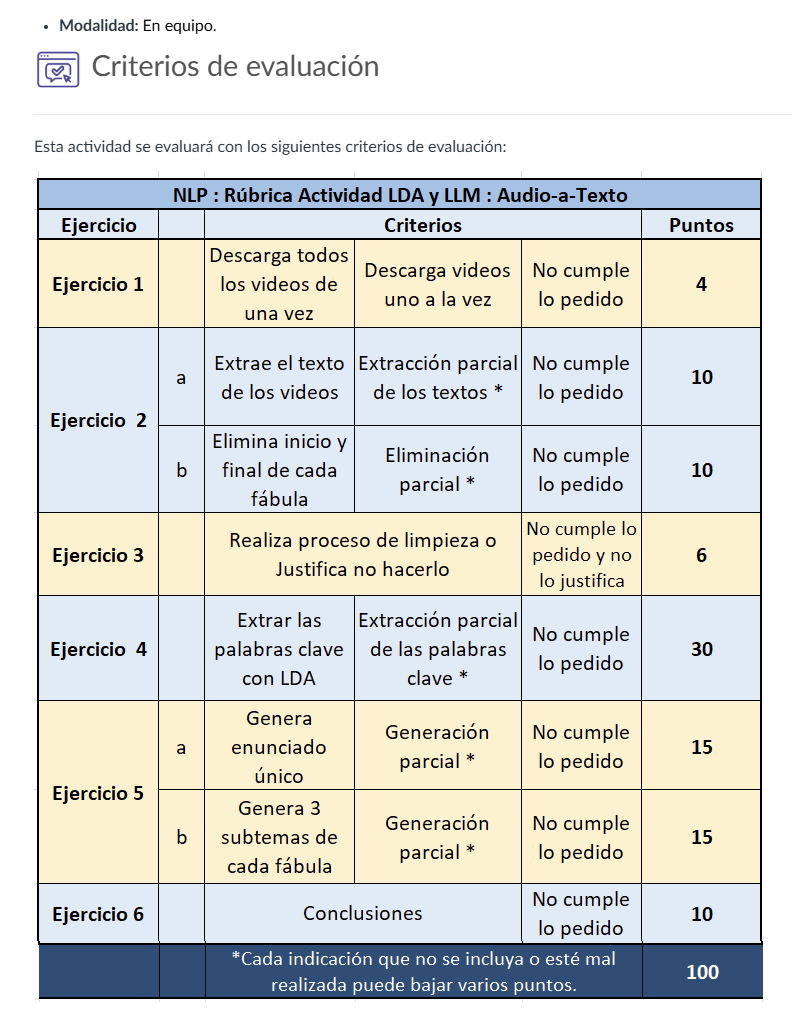